# Tutorial 
This notebook shows how to run PCR Simulation

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from scripts import erosion, helper, shoreline, slr, storm

In [29]:
import importlib
importlib.reload(storm)
importlib.reload(helper)
importlib.reload(slr)
importlib.reload(shoreline)

<module 'scripts.shoreline' from 'c:\\Users\\pba003\\Documents\\00projects\\pcr_python\\scripts\\shoreline.py'>

In [2]:
# set up a seed 
np.random.seed(42)

## All in one go
Import historical wave time series. This data can be acquired from wave hindcast or Buoy data

In [37]:
# test out the function using data from data/wave_srilanka.csv
# import wave data
wave_data = pd.read_csv('data/wave_srilanka.csv')

# get hs, dir, tp, time from dataframe
time = wave_data.iloc[:, 0].values
hs = wave_data.iloc[:, 1].values
dir = wave_data.iloc[:, 2].values
tp = wave_data.iloc[:, 3].values
ts_hs = 95
ts_dur = 12.0

# detect storm 
storms, storms_ts = storm.detect(hs, dir, tp, time, ts_hs, ts_dur)

# fit storm and gap 
fitted_storms = storm.fit_storm(storms)
fitted_gap = storm.fit_gap_monsoon(storms)

# generate storm sample
storms_sample = storm.generate(
    fitted_storm=fitted_storms, 
    sampling_size=1000, 
    oversample=0.1, 
    max_dur=np.max(storms.duration))

# add gaps
storms_sample = storm.sampling_gap_ecdf(
    fitted_gap=fitted_gap, 
    storms_sample=storms_sample
)

# simulating one sample 
date_start = datetime(
    year=2000, 
    month=1, 
    day=1
)

date_end = datetime(
    year=2100,
    month=12, 
    day=31
)

# generate storm time series from date start to date end
synthetic_storm = storm.generate_monsoon_ts(
    date_start=date_start, 
    date_end=date_end, 
    storms_sample=storms_sample, 
    fitted_gap=fitted_gap
)

# simulate sea level rise 
synthetic_storm['slr'] = slr.simulate_slr(
    synthetic_storm=synthetic_storm, 
    date_start=date_start, 
    scenario='RCP85', 
    wl0=0
)

# calculate storm-induced erosion
_, synthetic_storm['erosion_storm'] = erosion.mendoza(synthetic_storm)

# calculate recovery 
synthetic_storm['recovery'] = shoreline.calculate_recovery(
    storms=synthetic_storm,
    rec_rate=7/365
)

# calculate retreat due to slr 
synthetic_storm['slr_retreat'] = shoreline.calculate_slr_retreat(
    storms=synthetic_storm, 
    m=0.024
)

# track shoreline evolution 
shoreline_track = shoreline.track_shoreline(synthetic_storm)

In [ ]:
shoreline_track['time'] = helper.date_add_days(date_start, shoreline_track['day'])

px.line(
    shoreline_track,
    x='time', 
    y='shoreline_position', 
    labels={'time': 'Time', 'shoreline_position': 'Shoreline position (m)'},
    title=f'Shoreline Position'
)

## Monte carlo simulations

In [14]:
# set up a seed 
np.random.seed(42)

# Detect and fit storms
wave_data = pd.read_csv('data/wave_srilanka.csv')

# get hs, dir, tp, time from dataframe
time = wave_data.iloc[:, 0].values
hs = wave_data.iloc[:, 1].values
dir = wave_data.iloc[:, 2].values
tp = wave_data.iloc[:, 3].values
ts_hs = 95
ts_dur = 12.0

# detect storm 
storms, storms_ts = storm.detect(hs, dir, tp, time, ts_hs, ts_dur)

# fit storm and gap 
fitted_storms = storm.fit_storm(storms)
fitted_gap = storm.fit_gap_monsoon(storms)

# monte carlo simulations
date_start = datetime(
    year=2000, 
    month=1, 
    day=1
)

date_end = datetime(
    year=2100,
    month=12, 
    day=31
)

nr_simulation = 10000
nr_batch = 1000

stats = shoreline.run_monte_carlo(
    fitted_storms= fitted_storms,
    fitted_gap=fitted_gap,
    date_start=date_start, 
    date_end=date_end, 
    nr_simulation=nr_simulation, 
    nr_batch=nr_batch, 
    stat_kind='min',
    rec_rate=6.9/365,
    max_dur=np.max(storms.duration)
)



In [15]:
stats_68 = pd.DataFrame(stats.T)

In [33]:
# save stats as csv
stats_df = pd.DataFrame(stats.T)
stats_df.to_csv('data/stats_df_69.csv')


In [3]:
# save stats as csv
# stats_df = pd.DataFrame(stats.T)
# stats_df.to_csv('data/stats_df.csv')

# load csv as stats 
stats_df = pd.read_csv('data/stats_df_69.csv')

In [4]:
import scipy.io

stats_mat = scipy.io.loadmat('data/mins_10e5_noslr.mat')
stats_mat = stats_mat['mins_allSims']

stats_mat_df = pd.DataFrame(stats_mat.T)

In [8]:
recession_mat_df = -stats_mat_df
recession_df = -stats_df
recession_68 = -stats_68

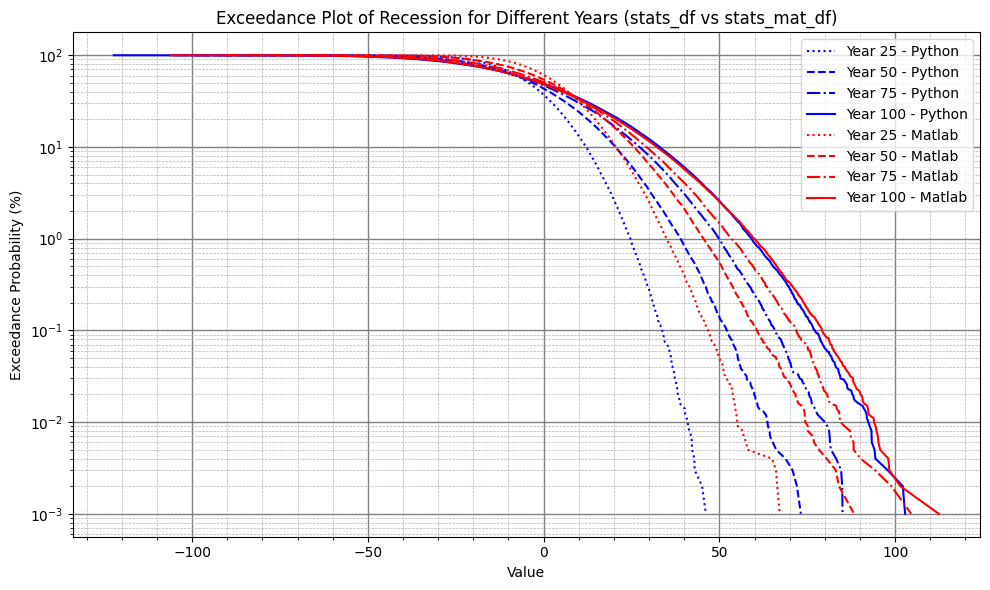

In [16]:
# Define the years of interest
years = [25, 50, 75, 100]
# years = [50, 100]


# Calculate exceedance (percentile) for each year
def get_exceedance(data, year):
    # Extract the column for the specific year
    year_data = data.iloc[:, year - 1]  # Adjusting for zero-based index
    # Calculate the exceedance for each year (sorted data)
    sorted_data = np.sort(year_data)
    exceedance = (1 - np.arange(len(sorted_data)) / len(sorted_data)) * 100
    return sorted_data, exceedance

# Prepare the plot
plt.figure(figsize=(10, 6))

# colors
linestyles = [':', '--', '-.', '-']
# linestyles = ['-.', '-']

# Plot for stats_df (solid line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(stats_df, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Python', linestyle=linestyles[i], color='b')

    
# # Plot for python new rec_rate
# for i, year in enumerate(years):
#     sorted_data, exceedance = get_exceedance(recession_68, year)
#     plt.plot(sorted_data, exceedance, label=f'Year {year} - Python', linestyle=linestyles[i], color='g')

# Plot for stats_mat_df (dashed line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(recession_mat_df, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Matlab', linestyle=linestyles[i], color='r')

# Labels and title
plt.xlabel('Value')
plt.ylabel('Exceedance Probability (%)')
plt.title('Exceedance Plot of Recession for Different Years (stats_df vs stats_mat_df)')
plt.legend()
plt.yscale('log')

# plt.xlim([-100, 100])
# plt.ylim([0.1, 100])

# Major and Minor Grid lines
plt.grid(visible=True, which='major', linestyle='-', linewidth=1, color='grey')  # Solid grid for major
plt.grid(visible=True, which='minor', linestyle='--', linewidth=0.5)  # Dashed grid for minor
plt.minorticks_on()  # Enable minor ticks

# Show plot
plt.tight_layout()
plt.show()

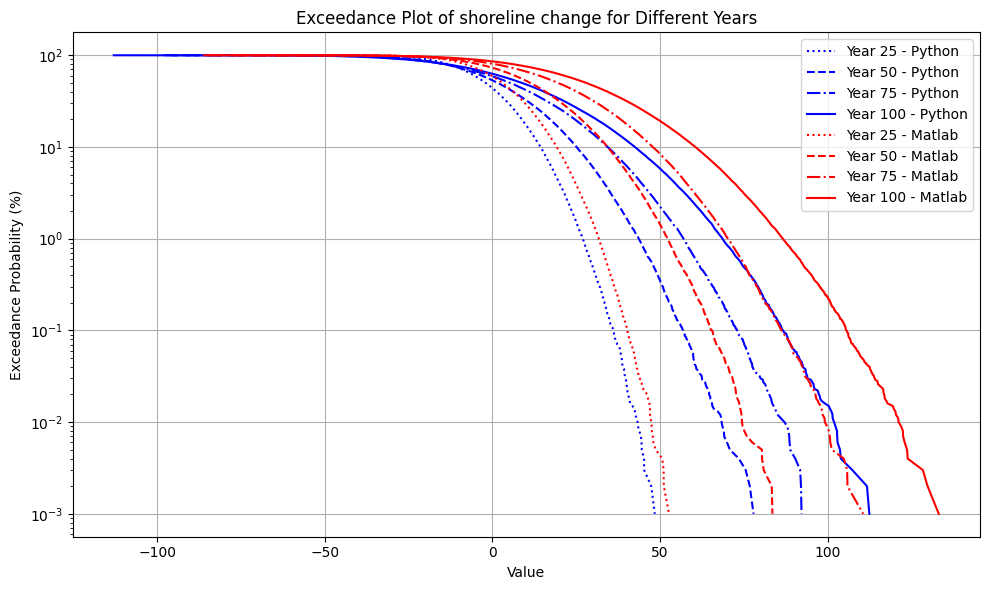

In [ ]:
# Define the years of interest
years = [25, 50, 75, 100]

# Calculate exceedance (percentile) for each year
def get_exceedance(data, year):
    # Extract the column for the specific year
    year_data = data.iloc[:, year - 1]  # Adjusting for zero-based index
    # Calculate the exceedance for each year (sorted data)
    sorted_data = np.sort(year_data)
    exceedance = (1 - np.arange(len(sorted_data)) / len(sorted_data)) * 100
    return sorted_data, exceedance

# Prepare the plot
plt.figure(figsize=(10, 6))

# colors
linestyles = [':', '--', '-.', '-']

# Plot for stats_df (solid line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(stats_df, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Python', linestyle=linestyles[i], color='b')

# Plot for stats_mat_df (dashed line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(stats_mat_df, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Matlab', linestyle=linestyles[i], color='r')

# Labels and title
plt.xlabel('Value')
plt.ylabel('Exceedance Probability (%)')
plt.title('Exceedance Plot of shoreline change for Different Years')
plt.legend()
plt.yscale('log')

# plt.xlim([-100, 100])
# plt.ylim([0.1, 100])

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


# Diagnosing The Problem 

In [ ]:
import mat73

In [ ]:
data_dict = mat73.loadmat('data/test/diagnostic_storm.mat')

# column of the storm track start day, hs, duration, tp
storm_track = data_dict['storm_track']

# remove nan values 
filtered_storm = storm_track[~np.isnan(storm_track).any(axis=1)]

# calculate end days and gap 
day_start = filtered_storm[:, 0] 
end_days = day_start + (filtered_storm[:, 2] / 24)

prev_day_end = np.concatenate([[filtered_storm[0, 0]], end_days[:-1]]) # leaving the first storm has 0 gap

# calculate gap and remove gap with lower than 0
gap_days =  day_start - prev_day_end 
gap_days[gap_days < 0] = 0

synthetic_matlab = pd.DataFrame({
    'hs': filtered_storm[:, 1],
    'duration': filtered_storm[:, 2],
    'tp': filtered_storm[:, 3],
    'day_start': day_start,
    'day_end': end_days,
    'gap': gap_days
}).astype(np.float32)

MemoryError: Unable to allocate 2.03 GiB for an array with shape (68049460, 4) and data type float64

In [ ]:
start_idx = np.where(day_start==0)
start_idx = start_idx[0]

end_idx = np.concat([start_idx[1:], [synthetic_matlab.iloc[-1].name]])

In [ ]:
start_idx = start_idx[0]

In [ ]:
sim_start

In [ ]:
start_idx[sim_start]

In [ ]:
sim_until

In [ ]:
sim_until = end_idx.shape[0] - 1

In [ ]:
slice_ts = synthetic_matlab.iloc[start_idx[sim_start]:end_idx[sim_until]].copy()

In [ ]:
slice_ts['slr_retreat'] = 0

# calculate storm-induced erosion
_, slice_ts['erosion_storm'] = erosion.mendoza(slice_ts)

slice_ts['recovery'] = shoreline.calculate_recovery(
    storms=slice_ts,
    rec_rate=7/365
)

In [ ]:
for i in range(sim_start, sim_until):
    temp_df = slice_ts.loc[start_idx[i]:end_idx[i]].copy()
    temp_track = shoreline.track_shoreline(temp_df)

    temp_row = shoreline.get_annual_statistics(temp_track, kind='min', date_start=date_start)
    # QUICK-FIX: force to have only 101 shape -> check later 
    # if temp_row.shape[0] >= 101:
    #     temp_row = temp_row[:101]
    # else:
    #     n_nan = 101-temp_row.shape[0]
    #     temp_row = np.concat([temp_row, np.full((n_nan, 1), np.nan)])

    if temp_row.shape[0] < 101:
        sim_count -= 1
    else:
        temp_row = temp_row[:101]
        mins_stat[:, sim_count] = temp_row.flatten()

    sim_count += 1

    if sim_count == nr_simulation:
        break

In [ ]:
# set date start and initiation
date_start = datetime(2000,1,1)
nr_simulation = 100000
mins_stat = np.empty((101, nr_simulation))
sim_count = 0
nr_batch = 1000
sim_start = 0

while sim_count < nr_simulation:
    sim_until = sim_start + nr_batch

    if sim_until > end_idx.shape[0]:
        sim_until = end_idx.shape[0] - 1

    # get a slice of one simulation 
    slice_ts = synthetic_matlab.iloc[start_idx[sim_start]:end_idx[sim_until]].copy()

    slice_ts['slr_retreat'] = 0

    # calculate storm-induced erosion
    _, slice_ts['erosion_storm'] = erosion.mendoza(slice_ts)

    slice_ts['recovery'] = shoreline.calculate_recovery(
        storms=slice_ts,
        rec_rate=7/365
    )

    for i in range(sim_start, sim_until):
        temp_df = slice_ts.loc[start_idx[i]:end_idx[i]].copy()
        temp_track = shoreline.track_shoreline(temp_df)

        temp_row = shoreline.get_annual_statistics(temp_track, kind='min', date_start=date_start)
        # QUICK-FIX: force to have only 101 shape -> check later 
        # if temp_row.shape[0] >= 101:
        #     temp_row = temp_row[:101]
        # else:
        #     n_nan = 101-temp_row.shape[0]
        #     temp_row = np.concat([temp_row, np.full((n_nan, 1), np.nan)])

        if temp_row.shape[0] < 101:
            sim_count -= 1
        else:
            temp_row = temp_row[:101]
            mins_stat[:, sim_count] = temp_row.flatten()

        sim_count += 1

        if sim_count == nr_simulation:
            break

    sim_start += nr_batch

In [ ]:
data_dict = mat73.loadmat('data/test/diagnostic_mins.mat')
mins_stat_mat = data_dict['mins_allSims']

mins_stat_py = mins_stat

In [ ]:
# Define the years of interest
years = [25, 50, 75, 100]

# Calculate exceedance (percentile) for each year
def get_exceedance(data, year):
    # Extract the column for the specific year
    year_data = data[year, :]  # Adjusting for zero-based index
    # Calculate the exceedance for each year (sorted data)
    sorted_data = np.sort(year_data)
    exceedance = (1 - np.arange(len(sorted_data)) / len(sorted_data)) * 100
    return sorted_data, exceedance

# Prepare the plot
plt.figure(figsize=(10, 6))

# colors
linestyles = [':', '--', '-.', '-']

# recession 
recession_min_py = -mins_stat_py
recession_min_mat = -mins_stat_mat

# Plot for stats_df (solid line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(recession_min_py, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Python', linestyle=linestyles[i], color='b')

# # Plot for stats_mat_df (dashed line)
for i, year in enumerate(years):
    sorted_data, exceedance = get_exceedance(recession_min_mat, year)
    plt.plot(sorted_data, exceedance, label=f'Year {year} - Matlab', linestyle=linestyles[i], color='r')

# Labels and title
plt.xlabel('Value')
plt.ylabel('Exceedance Probability (%)')
plt.title('Exceedance Plot of shoreline change for Different Years')
plt.legend()
plt.yscale('log')

plt.xlim([-100, 100])
plt.ylim([0.1, 100])

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from datetime import datetime 
from scripts import storm 

import numpy as np
import pandas as pd

def generate_monsoon_ts_mod(date_start: datetime, date_end: datetime, storms_sample: pd.DataFrame, fitted_gap: pd.DataFrame, start_storm: int = 0) -> pd.DataFrame: 
    '''
    Function to generate one simulation from date_start to date_end 
    '''

    sim_days = (date_end-date_start).days
    sim_years = date_end.year-date_start.year
    size_year = int(sim_years*1.2)
    size_storm = len(storms_sample)
    dur_day = storms_sample['duration']/24

    # sample year storm season length
    year_sample = np.random.poisson(lam=fitted_gap['lambda_year'], size=size_year)
    season_sample = np.random.poisson(lam=fitted_gap['lambda_season'], size=size_year)

    storm_count = start_storm
    season_count = 0
    day_count = 0
    storm_synth = []

    # Precompute values for storms to avoid redundant lookups
    hs_values = storms_sample['hs'].values
    dir_values = storms_sample['direction'].values
    dur_values = storms_sample['duration'].values
    tp_values = storms_sample['tp'].values
    gap_values = storms_sample['gap'].values

    while day_count < sim_days:
        # fill the storm season
        start_season = day_count
        end_season = day_count + season_sample[season_count] 
        
        while (day_count < end_season) and (day_count < sim_days):
            
            if storm_count >= size_storm:
                raise ValueError('samples are exhausted')
            
            hs_i = hs_values[storm_count]
            dir_i = dir_values[storm_count]
            dur_i = dur_values[storm_count]
            tp_i = tp_values[storm_count]
            start_i = day_count
            end_i = day_count + dur_day[storm_count]

            day_count += dur_day[storm_count] + gap_values[storm_count]
            storm_count += 1

            storm_synth.append({
                'hs': hs_i, 
                'direction': dir_i,
                'duration': dur_i,
                'tp': tp_i,
                'day_start': start_i,
                'day_end': end_i
            })

        # move to the next season
        day_count = start_season + year_sample[season_count]
        season_count += 1

    synthetic_storm = pd.DataFrame(storm_synth)

    # gap is defined as the day length from the end of last storm to the start of this storm
    # day_end = synthetic_storm["day_end"].values
    # next_day_start = np.concatenate([synthetic_storm["day_start"][1:].values, [synthetic_storm["day_end"].iloc[-1]]]) # leaving the last storm has 0 gap
    
    # synthetic_storm["gap"] = next_day_start-day_end

    day_start = synthetic_storm["day_start"].values
    prev_day_end = np.concatenate([[synthetic_storm["day_start"].iloc[0]], synthetic_storm["day_end"][:-1].values]) # leaving the first storm has 0 gap

    synthetic_storm['gap'] = day_start - prev_day_end

    return synthetic_storm

In [ ]:
# test out the function using data from data/wave_srilanka.csv
# import wave data
wave_data = pd.read_csv('data/wave_srilanka.csv')

# get hs, dir, tp, time from dataframe
time = wave_data.iloc[:, 0].values
hs = wave_data.iloc[:, 1].values
dir = wave_data.iloc[:, 2].values
tp = wave_data.iloc[:, 3].values
ts_hs = 95
ts_dur = 12.0

# detect storm 
storms, storms_ts = storm.detect(hs, dir, tp, time, ts_hs, ts_dur)

# fit storm and gap 
fitted_storms = storm.fit_storm(storms)
fitted_gap = storm.fit_gap_monsoon(storms)

# generate storm sample
storms_sample = storm.generate(
    fitted_storm=fitted_storms, 
    sampling_size=1000, 
    oversample=0.1, 
    max_dur=np.max(storms.duration))

# add gaps
storms_sample = storm.sampling_gap_ecdf(
    fitted_gap=fitted_gap, 
    storms_sample=storms_sample
)

# simulating one sample 
date_start = datetime(
    year=2000, 
    month=1, 
    day=1
)

date_end = datetime(
    year=2100,
    month=12, 
    day=31
)

In [ ]:
# generate storm time series from date start to date end
synthetic_storm = storm.generate_monsoon_ts(
    date_start=date_start, 
    date_end=date_end, 
    storms_sample=storms_sample, 
    fitted_gap=fitted_gap
)